In [1]:
# Imports

import ray

import IPython.core.display_functions

from src.parsers import HMParser, CotevParser
from src.algorithms.rl import EnergyCommunityEntropyPriorityV0

from src.utils import load_multiple_upacs_pv, iterate_resources, create_ppo_policies

import warnings
warnings.filterwarnings('ignore')

2025-05-06 23:52:14,445	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!
2025-05-06 23:52:14,709	WARNING deprecation.py:50 -- DeprecationWarning: `build_tf_policy` has been deprecated. This will raise an error in the future!
2025-05-06 23:52:14,712	WARNING deprecation.py:50 -- DeprecationWarning: `build_policy_class` has been deprecated. This will raise an error in the future!


In [2]:
# Data parsing

# EC data for non-renewable generators and batteries
data_ec = HMParser(file_path='/Users/ecgomes/DataspellProjects/pyecom/data/EC_V4.xlsx', ec_id=1)
data_ec.parse()

# EV data from the EV4EU simulator
data_ev = CotevParser(population_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/population_731.csv',
                      driving_history_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/ev_driving_history_731.csv',
                      assigned_segments_path='/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/assigned_segments_731.csv',
                      parse_date_start='2019',
                      parse_date_end='2020')
data_ev.parse()

# UPAC Data load
data_upacs = load_multiple_upacs_pv('/Users/ecgomes/Documents/PhD/UPAC data/upac*_pv.csv', resample='H')

In [3]:
# Create resources for the training environment

dataset_resources = iterate_resources(u=data_upacs, c=data_ec, e=data_ev, mode='monthly')

In [4]:
# Create the environment and check if everything is ok

temp_env = EnergyCommunityEntropyPriorityV0(ren_generators=dataset_resources[
                                                                    list(dataset_resources.keys())[0]][:5],
                                                 generators=[],
                                                 loads=dataset_resources[list(dataset_resources.keys())[0]][5:10],
                                                 storages=dataset_resources[list(dataset_resources.keys())[0]][10:13],
                                                 evs=dataset_resources[list(dataset_resources.keys())[0]][13:-1],
                                                 aggregator=dataset_resources[list(dataset_resources.keys())[0]][-1],
                                                 storage_penalty=1,
                                                 ev_penalty=1,
                                                 balance_penalty=1,
                                                 look_ahead=12)
temp_env.reset()
terminations = truncations = {a: False for a in temp_env.agents}
terminations['__all__'] = False
truncations['__all__'] = False
while not terminations['__all__'] and not truncations['__all__']:
        
    actions = temp_env.action_space.sample()
    next_obs, rewards, terminations, truncations, infos = temp_env.step(actions)

print('Terminated: {}'.format(terminations['__all__']))

{'ev_01': {'discharge_cost': 0.05, 'charge_cost': 0.0, 'soc': 0.2, 'connected': 1, 'max_discharge_power': 7.2, 'max_charge_power': 7.2, 'grid_balance': -6.27151}, 'ev_02': {'discharge_cost': 0.05, 'charge_cost': 0.0, 'soc': 0.2, 'connected': 1, 'max_discharge_power': 7.2, 'max_charge_power': 7.2, 'grid_balance': -6.27151}, 'ev_03': {'discharge_cost': 0.05, 'charge_cost': 0.0, 'soc': 0.2, 'connected': 1, 'max_discharge_power': 7.2, 'max_charge_power': 7.2, 'grid_balance': -6.27151}, 'ev_04': {'discharge_cost': 0.05, 'charge_cost': 0.0, 'soc': 0.2, 'connected': 1, 'max_discharge_power': 7.2, 'max_charge_power': 7.2, 'grid_balance': -6.27151}, 'ev_05': {'discharge_cost': 0.05, 'charge_cost': 0.0, 'soc': 0.2, 'connected': 1, 'max_discharge_power': 7.2, 'max_charge_power': 7.2, 'grid_balance': -6.27151}, 'storage_01': {'discharge_cost': 0.4, 'charge_cost': 0.0, 'soc': 0.8, 'connected': 1.0, 'max_discharge_power': 10.0, 'max_charge_power': 10.0, 'grid_balance': -6.27151}, 'storage_02': {'dis

In [6]:
temp_env.priority_system.priorities

,ev_01,ev_02,ev_03,ev_04,ev_05,storage_01,storage_02,storage_03
0,-0.562727,-0.562727,-0.562727,-0.562727,-0.562727,-0.219953,0.562484,-0.764808
1,-0.504631,-0.504631,-0.504631,-0.504631,-0.504631,-0.161856,0.620581,-0.706712
2,-0.416566,-0.416566,-0.416566,-0.416566,-0.416566,-0.073791,0.708646,-0.618647
3,0.011336,0.011336,0.011336,0.011336,0.011336,0.354110,1.136547,-0.190746
4,0.074907,0.074907,0.074907,0.074907,0.074907,0.417682,1.200118,-0.127174
...,...,...,...,...,...,...,...,...
739,0.847775,0.847775,0.847775,0.847775,0.847775,1.190550,1.972987,0.645694
740,0.847775,0.847775,0.847775,0.847775,0.847775,1.190550,1.972987,0.645694
741,0.847775,0.847775,0.847775,0.847775,0.847775,1.190550,1.972987,0.645694
742,0.847775,0.847775,0.847775,0.847775,0.847775,1.190550,1.972987,0.645694


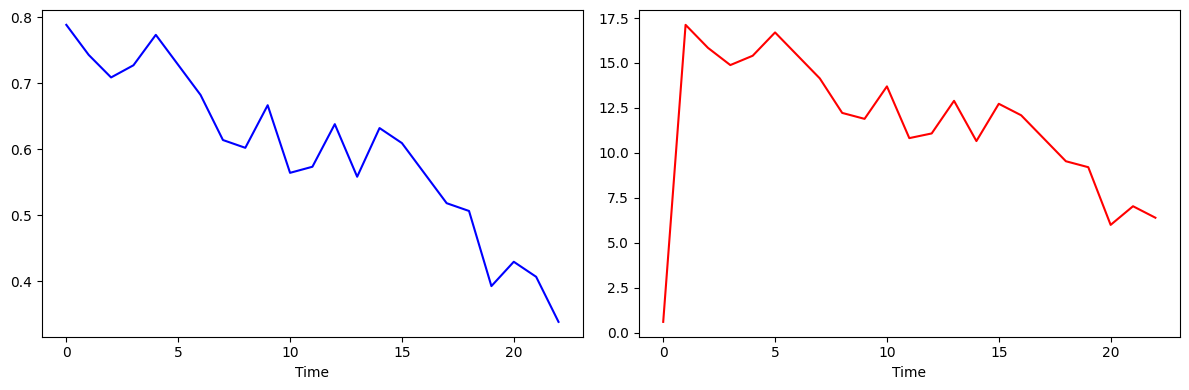

In [5]:
# Plot the values of the EV 01 over time, as well as the priority in another axis

import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))
axs[0].plot(temp_env.evs[0].value[:23], color='blue', label='EV 01 value')
axs[0].set_xlabel('Time')

axs[1].plot(temp_env.priority_system.priorities['ev_01'].iloc[:23], color='red', label='EV 01 priority')
axs[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

<Axes: >

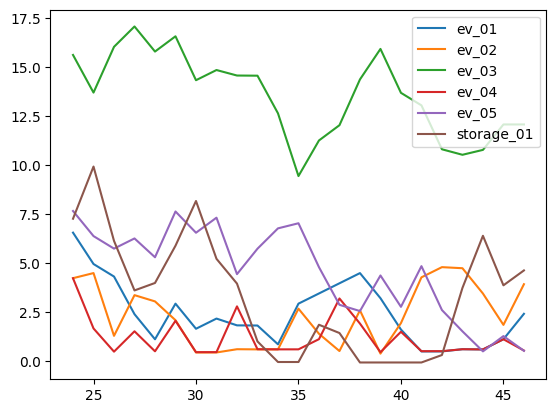

In [6]:
temp_env.priority_system.priorities.iloc[24:47][['ev_01', 'ev_02', 'ev_03', 'ev_04', 'ev_05',
                                               'storage_01',]].plot()

In [5]:
# Create the policies to train

# The keys of the dictionary respect the class names of the agents
gammas = {'Generator': 0.0, 'Storage': 0.9, 'Vehicle': 0.9, 'Aggregator': 0.9}

# Create the policies, one for each agent. Each policy has the name of the agent.
policies = create_ppo_policies(temp_env, gammas)

2025-03-04 02:10:13,533	WARNING algorithm_config.py:2578 -- Setting `exploration_config={}` because you set `_enable_rl_module_api=True`. When RLModule API are enabled, exploration_config can not be set. If you want to implement custom exploration behaviour, please modify the `forward_exploration` method of the RLModule at hand. On configs that have a default exploration config, this must be done with `config.exploration_config={}`.
2025-03-04 02:10:13,534	WARNING algorithm_config.py:2578 -- Setting `exploration_config={}` because you set `_enable_rl_module_api=True`. When RLModule API are enabled, exploration_config can not be set. If you want to implement custom exploration behaviour, please modify the `forward_exploration` method of the RLModule at hand. On configs that have a default exploration config, this must be done with `config.exploration_config={}`.
2025-03-04 02:10:13,534	WARNING algorithm_config.py:2578 -- Setting `exploration_config={}` because you set `_enable_rl_module

In [6]:
# Create individual networks for each agent

model_cfgs = {}
for agent in temp_env.agents:
    
    if agent.startswith('storage'):
        model_cfg = {'use_lstm': True,
                     'lstm_cell_size': 128,
                     'fcnet_hiddens': [32, 32],
                     'fcnet_activation': 'relu',
                     'lstm_use_prev_action': True,
                     'lstm_use_prev_reward': True,
                     'vf_share_layers': False}
        
    elif agent.startswith('ev'):
        model_cfg = {'use_lstm': True,
                     'lstm_cell_size': 128,
                     'fcnet_hiddens': [32, 32],
                     'fcnet_activation': 'relu',
                     'lstm_use_prev_action': True,
                     'lstm_use_prev_reward': True,
                     'vf_share_layers': False}
        
    else:
        model_cfg = {'fcnet_hiddens': [1],}
        
    model_cfgs[agent] = model_cfg

In [16]:
# Create an RLlib Algorithm instance from a PPOConfig to learn how to
# act in the above environment.

from ray.tune import register_env
from ray import tune, train
from ray.air import CheckpointConfig
from ray.tune.schedulers import AsyncHyperBandScheduler
from ray.rllib.algorithms.ppo import PPOConfig

ray.shutdown()
ray.init()

IMPORT_PENALTY = 1 #100
EXPORT_PENALTY = 1 #10
STORAGE_ACTION_PENALTY = 50 # 100
STORAGE_ACTION_REWARD = 5 #10
EV_ACTION_PENALTY = 1 #1000
EV_ACTION_REWARD = 5 #10
EV_REQUIREMENT_PENALTY = 50 #3000
BALANCE_PENALTY = 5000 #20000

MAX_ITER = 50

checkpoint = None
checkpoint_path = None
algo = None
current_best = None

# Build a loop for using separate resources on a daily basis
# for datapoint in list(dataset_resources.keys())[1:2]:
    
temp_resources = dataset_resources['2019-01']

env = EnergyCommunityContributionPriorityV4(ren_generators=temp_resources[:5],
                                            generators=[],
                                            loads=temp_resources[5:10],
                                            storages=temp_resources[10:13],
                                            evs=temp_resources[13:-1],
                                            aggregator=temp_resources[-1],
                                            storage_penalty=STORAGE_ACTION_PENALTY,
                                            ev_penalty=EV_REQUIREMENT_PENALTY,
                                            balance_penalty=BALANCE_PENALTY,
                                            look_ahead=12)
register_env("EC_Contrib_V4", lambda config: env)

# Define the PPOConfig
_config = (PPOConfig()
           .environment(env="EC_Contrib_V4", disable_env_checking=False)
           .training(train_batch_size=256,
                     lr=5e-5,
                     gamma=0.99,
                     use_gae=True,
                     use_critic=True,
                     use_kl_loss=True,
                     clip_param=0.1,
                     grad_clip=4,
                     )
           .exploration(exploration_config={})
           .framework('torch')
           .multi_agent(policies=policies,
                        policies_to_train=list(policies.keys())[:-1],
                        policy_mapping_fn=(lambda agent_id, episode, worker, **kwargs: 
                                           agent_id),
                        algorithm_config_overrides_per_module=model_cfgs)
           .rollouts(batch_mode='complete_episodes', #'complete_episodes',
                     num_rollout_workers=10,
                     rollout_fragment_length='auto'))

# Clear the Jupyter cell output
IPython.core.display_functions.clear_output()

scheduler = AsyncHyperBandScheduler(time_attr="training_iteration",
                                    max_t=MAX_ITER,
                                    metric="episode_reward_mean",
                                    mode="max",
                                    grace_period=10)

# Train the algorithm with Tuner
tuner = tune.Tuner(
    "PPO",
    param_space=_config,
    run_config=train.RunConfig(stop={'training_iteration': MAX_ITER, 'episode_reward_mean': -40.0},
                               checkpoint_config=CheckpointConfig(checkpoint_frequency=10,
                                                                  checkpoint_at_end=True),
                               verbose=1),
    tune_config=tune.TuneConfig(scheduler=scheduler, num_samples=1),
)
    
results = tuner.fit()

2025-03-04 09:58:31,021	INFO tune.py:645 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
2025-03-04 09:58:31,026	WARNING algorithm_config.py:2578 -- Setting `exploration_config={}` because you set `_enable_rl_module_api=True`. When RLModule API are enabled, exploration_config can not be set. If you want to implement custom exploration behaviour, please modify the `forward_exploration` method of the RLModule at hand. On configs that have a default exploration config, this must be done with `config.exploration_config={}`.
2025-03-04 09:58:31,030	WARNING algorithm_config.py:2578 -- Setting `exploration_config={}` because you set `_enable_rl_module_api=True`. When RLModule API are enabled, exploration_config can not be set. If you want to implement custom exploration behaviour, please modify the `forward_exploration` method of the RL

2025-03-04 10:01:23,131	INFO tune.py:1143 -- Total run time: 172.11 seconds (162.06 seconds for the tuning loop).
2025-03-04 10:01:23,131	WARNING tune.py:1158 -- Experiment has been interrupted, but the most recent state was saved.
Resume experiment with: Tuner.restore(path="/Users/ecgomes/ray_results/PPO_2025-03-04_09-58-31", trainable=...)


In [9]:
 results.get_best_result('episode_reward_mean', 'max').get_best_checkpoint('episode_reward_mean', 'max').path

'/Users/ecgomes/ray_results/PPO_2025-03-03_16-25-33/PPO_EC_Contrib_V4_2169f_00000_0_2025-03-03_16-25-33/checkpoint_000000'

Checkpoint path:
'/Users/ecgomes/ray_results/PPO_2025-02-18_15-09-08/PPO_EC_Contrib_V4_4d02e_00000_0_2025-02-18_15-09-08/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-18_18-10-32/PPO_EC_Contrib_V4_a4c58_00000_0_2025-02-18_18-10-32/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-18_19-40-43/PPO_EC_Contrib_V4_3d974_00000_0_2025-02-18_19-40-43/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-18_20-40-48/PPO_EC_Contrib_V4_a2603_00000_0_2025-02-18_20-40-48/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-19_00-32-59/PPO_EC_Contrib_V4_11fd2_00000_0_2025-02-19_00-32-59/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-19_11-11-03/PPO_EC_Contrib_V4_356af_00000_0_2025-02-19_11-11-03/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-19_16-48-03/PPO_EC_Contrib_V4_492d8_00000_0_2025-02-19_16-48-03/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-19_20-41-24/PPO_EC_Contrib_V4_e2566_00000_0_2025-02-19_20-41-24/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-19_22-22-13/PPO_EC_Contrib_V4_f8247_00000_0_2025-02-19_22-22-13/checkpoint_000000'
^ cost as metric

'/Users/ecgomes/ray_results/PPO_2025-02-20_02-18-08/PPO_EC_Contrib_V4_ecf1c_00000_0_2025-02-20_02-18-08/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-20_17-24-11/PPO_EC_Contrib_V4_7ffb8_00000_0_2025-02-20_17-24-11/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-20_19-35-46/PPO_EC_Contrib_V4_e1a4e_00000_0_2025-02-20_19-35-46/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-20_22-31-48/PPO_EC_Contrib_V4_794c3_00000_0_2025-02-20_22-31-48/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-21_03-45-27/PPO_EC_Contrib_V4_4a0ea_00000_0_2025-02-21_03-45-27/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-21_14-22-22/PPO_EC_Contrib_V4_4403d_00000_0_2025-02-21_14-22-22/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-21_16-07-48/PPO_EC_Contrib_V4_fec67_00000_0_2025-02-21_16-07-48/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-22_23-31-37/PPO_EC_Contrib_V4_29666_00000_0_2025-02-22_23-31-37/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-23_00-01-03/PPO_EC_Contrib_V4_45ff2_00000_0_2025-02-23_00-01-03/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-23_00-07-14/PPO_EC_Contrib_V4_22bce_00000_0_2025-02-23_00-07-14/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-23_19-55-57/PPO_EC_Contrib_V4_32c0a_00000_0_2025-02-23_19-55-57/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-23_23-13-56/PPO_EC_Contrib_V4_db73b_00000_0_2025-02-23_23-13-57/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-24_03-44-21/PPO_EC_Contrib_V4_a2229_00000_0_2025-02-24_03-44-21/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-24_14-32-39/PPO_EC_Contrib_V4_33228_00000_0_2025-02-24_14-32-39/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-24_16-58-03/PPO_EC_Contrib_V4_832e6_00000_0_2025-02-24_16-58-03/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-28_09-31-54/PPO_EC_Contrib_V4_d8c6c_00000_0_2025-02-28_09-31-54/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-28_10-26-44/PPO_EC_Contrib_V4_82196_00000_0_2025-02-28_10-26-44/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-28_14-04-14/PPO_EC_Contrib_V4_e46a4_00000_0_2025-02-28_14-04-14/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-28_14-58-57/PPO_EC_Contrib_V4_8973d_00000_0_2025-02-28_14-58-57/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-02-28_20-31-52/PPO_EC_Contrib_V4_0b3ab_00000_0_2025-02-28_20-31-52/checkpoint_000000'

'/Users/ecgomes/ray_results/PPO_2025-03-03_16-25-33/PPO_EC_Contrib_V4_2169f_00000_0_2025-03-03_16-25-33/checkpoint_000000'

/Users/ecgomes/ray_results/PPO_2025-03-04_11-33-47/PPO_EC_Contrib_V4_89c32_00000_0_2025-03-04_11-33-47/checkpoint_000022

In [21]:
results.get_best_result('episode_reward_mean', 'max').get_best_checkpoint('episode_reward_mean', mode='max')

RuntimeError: No checkpoint exists in the trial directory!

In [24]:
new_list = [x for x in temp_env.agents.keys() if 'aggregator' not in x]

In [25]:
new_list

['ev_01',
 'ev_02',
 'ev_03',
 'ev_04',
 'ev_05',
 'storage_01',
 'storage_02',
 'storage_03']

In [27]:
new_list.append('aggregator')
new_list

['ev_01',
 'ev_02',
 'ev_03',
 'ev_04',
 'ev_05',
 'storage_01',
 'storage_02',
 'storage_03',
 'aggregator']

In [28]:
for i in new_list:
    print(i)

ev_01
ev_02
ev_03
ev_04
ev_05
storage_01
storage_02
storage_03
aggregator
